In [1]:
import pandas as pd
import numpy as np

In [2]:
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";")

In [3]:
from general_information import read_actions, read_balances, read_payments
actions = read_actions()
payments = read_payments()
balance = read_balances()
balance = balance[balance["ЛС"].notna()]


In [4]:
df_pay.head()

,Номер,Дата оплаты,Сумма,Способ оплаты
0,15,24.01.2025,100,5.0
1,15,25.01.2026,1240,5.0
2,15,25.05.2025,"293,96",5.0
3,15,25.06.2025,10,5.0
4,15,26.02.2025,"289,56",5.0


In [5]:
df_pay.groupby(by="Номер",as_index=False).agg({"Сумма": "count"})

,Номер,Сумма
0,15,16
1,16,15
2,17,13
3,18,15
4,20,13
...,...,...
128717,147099,16
128718,147100,14
128719,147101,15
128720,147102,15


In [6]:
from form_time_features import extract_payment_features

payment_features = extract_payment_features(payments, k=3, current_date=pd.to_datetime('2026-04-23'))
print(df_pay['Номер'].unique().shape, payment_features.shape)
print(f"Число неплатёжников: {(payment_features['Платежей_за_последние_3_мес'] == 0).sum()}")
payment_features.head()

(128722,) (128722, 3)
Число неплатёжников: 14205


,Id,Дней_с_последнего_платежа,Платежей_за_последние_3_мес
0,15,26,3
1,16,36,2
2,17,42,1
3,18,39,2
4,20,40,1


In [ ]:
def calculate_complex_features_actions_based(
    pay_df: pd.DataFrame,
    balances: pd.DataFrame,
    actions: pd.DataFrame,
    k: int,
    no_payment_const=9999
) -> pd.DataFrame:

    all_actions = list(actions.keys())

    # --- собираем действия ---
    action_rows = []
    for name, info in actions.items():
        tmp = info["data"].copy()
        tmp = tmp.rename(columns={tmp.columns[0]: "ЛС"})
        tmp["date"] = pd.to_datetime(tmp.iloc[:, 1])
        tmp["action"] = name
        tmp["stage"] = info.get("stage", "unknown")
        action_rows.append(tmp[["ЛС", "action", "stage", "date"]])

    actions_df = pd.concat(action_rows, ignore_index=True)
    actions_df["ЛС"] = actions_df["ЛС"].astype(int)

    pay_df = pay_df.copy()
    pay_df["Дата оплаты"] = pd.to_datetime(pay_df["Дата оплаты"], dayfirst=True, errors="coerce")
    pay_df = pay_df.dropna(subset=["Дата оплаты"])
    pay_df = pay_df.rename(columns={"Номер": "ЛС"})
    pay_df["Year"] = pay_df["Дата оплаты"].dt.year
    pay_df["Month"] = pay_df["Дата оплаты"].dt.month

    events = actions_df.copy()
    events["curr_date"] = pd.to_datetime(events["date"])
    events = events[["ЛС", "curr_date", "action"]].sort_values(["ЛС", "curr_date"])

    # --- balances → long ---
    balances["ЛС"] = balances["ЛС"].astype(int)
    melted = balances.melt(id_vars=["ЛС"], var_name="Period", value_name="Value")
    extracted = melted["Period"].str.extract(r"(?P<Year>\d{4})_(?P<Month>\d+)_(?P<Metric>[a-zA-Z]+)")
    melted = pd.concat([melted, extracted], axis=1)

    melted["Year"] = melted["Year"].astype(int)
    melted["Month"] = melted["Month"].astype(int)

    long_df = melted.pivot_table(
        index=["ЛС", "Year", "Month"],
        columns="Metric",
        values="Value",
        aggfunc="first"
    ).reset_index()

    long_df["Period_Date"] = pd.to_datetime(
        long_df["Year"].astype(str) + "-" + long_df["Month"].astype(str) + "-01"
    )

    long_df["end_balance"] = long_df["start"] - long_df["paid"]

    # --- 🔴 КЛЮЧ: находим месяцы полного закрытия ---
    cleared = long_df[long_df["end_balance"] <= 0][["ЛС", "Year", "Month", "Period_Date"]]

    # --- находим дату последнего платежа в месяце закрытия ---
    clearance_pay = cleared.merge(
        pay_df,
        on=["ЛС", "Year", "Month"],
        how="left"
    )

    clearance_dates = (
        clearance_pay
        .groupby(["ЛС", "Period_Date"])["Дата оплаты"]
        .max()
        .reset_index()
        .rename(columns={"Дата оплаты": "clearance_date"})
    )

    clearance_dates = clearance_dates.dropna(subset=["clearance_date"])
    clearance_dates["clearance_date"] = pd.to_datetime(
        clearance_dates["clearance_date"], errors="coerce"
    )

    # --- теперь делаем asof join по событиям ---
    events_sorted = events.sort_values(["curr_date", "ЛС"])
    clearance_dates = clearance_dates.sort_values(["clearance_date", "ЛС"])

    last_clearance = pd.merge_asof(
        events_sorted,
        clearance_dates,    
        left_on="curr_date",
        right_on="clearance_date",
        by="ЛС",
        direction="backward"
    )

    last_clearance["Days_Since_Clearance"] = (
        last_clearance["curr_date"] - last_clearance["clearance_date"]
    ).dt.days

    last_clearance["Days_Since_Clearance"] = last_clearance["Days_Since_Clearance"].fillna(no_payment_const)

    # --- остальные признаки (по той же логике, но через фильтр по curr_date) ---

    # приклеим long_df к событиям
    long_ev = events.merge(long_df, on="ЛС", how="left")
    long_ev = long_ev[long_ev["Period_Date"] < long_ev["curr_date"]]

    # --- Payment_Fraction_12M ---
    mask_12m = long_ev["Period_Date"] >= (long_ev["curr_date"] - pd.DateOffset(months=12))
    tmp_12m = long_ev[mask_12m]

    paid_fraction = (
        tmp_12m.groupby(["ЛС", "curr_date"])
        .apply(lambda x: (x["paid"] > 0).mean())
        .reset_index(name="Payment_Fraction_12M")
    )

    # --- debt streak ---
    long_ev = long_ev.sort_values(["ЛС", "curr_date", "Period_Date"], ascending=[True, True, False])
    long_ev["has_debt"] = (long_ev["end_balance"] > 0).astype(int)
    long_ev["debt_streak"] = long_ev.groupby(["ЛС", "curr_date"])["has_debt"].cumprod()

    debt_age = (
        long_ev.groupby(["ЛС", "curr_date"])["debt_streak"]
        .sum()
        .reset_index(name="Consecutive_Debt_Months")
    )

    # --- ratio ---
    mask_k = long_ev["Period_Date"] >= (long_ev["curr_date"] - pd.DateOffset(months=k+1))
    tmp_k = long_ev[mask_k].sort_values(["ЛС", "curr_date", "Period_Date"])

    sum_k = tmp_k.groupby(["ЛС", "curr_date"])[["paid", "accr"]].sum().reset_index()

    sum_k["Payment_Accrual_Ratio_kM"] = np.where(
        sum_k["accr"] > 0,
        sum_k["paid"] / sum_k["accr"],
        1
    )

    # --- current debt ---
    latest_balance = (
        long_ev.sort_values(["ЛС", "curr_date", "Period_Date"], ascending=[True, True, False])
        .groupby(["ЛС", "curr_date"])
        .first()
        .reset_index()[["ЛС", "curr_date", "start", "Period_Date"]]
    )

    pays = pay_df.copy()

    pays_ev = events.merge(pays, on="ЛС", how="left")
    pays_ev = pays_ev[pays_ev["Дата оплаты"] <= pays_ev["curr_date"]]

    pays_ev = pays_ev.merge(
        latest_balance[["ЛС", "curr_date", "Period_Date"]],
        on=["ЛС", "curr_date"],
        how="left"
    )

    pays_ev = pays_ev[pays_ev["Дата оплаты"] >= pays_ev["Period_Date"]]

    recent_pays = (
        pays_ev.groupby(["ЛС", "curr_date"])["Сумма"]
        .sum()
        .reset_index(name="Recent_Payments")
    )

    debt = latest_balance.merge(recent_pays, on=["ЛС", "curr_date"], how="left")
    debt["Recent_Payments"] = debt["Recent_Payments"].fillna(0)
    debt["Current_Debt"] = debt["start"] - debt["Recent_Payments"]

    # --- финальная сборка ---
    result = events.copy()

    for df_ in [
        last_clearance[["ЛС", "curr_date", "Days_Since_Clearance"]],
        paid_fraction,
        debt_age,
        sum_k[["ЛС", "curr_date", "Payment_Accrual_Ratio_kM"]],
        debt[["ЛС", "curr_date", "Current_Debt"]],
    ]:
        result = result.merge(df_, on=["ЛС", "curr_date"], how="left")

    result["Payment_Fraction_12M"] = result["Payment_Fraction_12M"].fillna(0)
    result["Consecutive_Debt_Months"] = result["Consecutive_Debt_Months"].fillna(0)
    result["Payment_Accrual_Ratio_kM"] = result["Payment_Accrual_Ratio_kM"].fillna(1)

    # --- Число дней после условных аванса (5 число) и зарплаты (20 число) ---
    # Поскольку current_date едина для всего датафрейма в рамках вызова функции,
    # мы рассчитываем эти значения один раз и присваиваем всем
    def days_since_target_day(dates: pd.Series, target_day: int) -> pd.Series:
        dates = pd.to_datetime(dates)

        # день месяца
        day = dates.dt.day

        # дата с тем же месяцем
        this_month_target = dates.dt.to_period("M").dt.to_timestamp() + pd.offsets.Day(target_day - 1)

        # дата в прошлом месяце
        prev_month = (dates - pd.DateOffset(months=1))
        prev_month_target = prev_month.dt.to_period("M").dt.to_timestamp() + pd.offsets.Day(target_day - 1)

        # выбираем
        last_target = np.where(
            day >= target_day,
            this_month_target,
            prev_month_target
        )

        last_target = pd.to_datetime(last_target)

        return (dates - last_target).dt.days



    days_since_5th = days_since_target_day(result["curr_date"], 5)
    days_since_20th = days_since_target_day(result["curr_date"], 20)
    
    result['Days_Since_Advance_5th'] = days_since_5th
    result['Days_Since_Salary_20th'] = days_since_20th

    # Отбрасываем людей, которым звонили 1 января 2025 года <- мы не знаем их долг
    resilt = result[complex_features["Current_Debt"].notna()]

    return result

In [16]:
# from form_time_features import calculate_complex_features, calculate_complex_features_actions_based

# complex_features = calculate_complex_features(payments, balance, k=3, curr_date=pd.to_datetime('2026-01-23'))
complex_features = calculate_complex_features_actions_based(payments, balance, actions, k=3)
complex_features.head()

<class 'pandas.DataFrame'>
Index: 348205 entries, 4 to 212795
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ЛС         348205 non-null  int64         
 1   curr_date  348205 non-null  datetime64[us]
 2   action     348205 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 10.6 MB
None
<class 'pandas.DataFrame'>
Index: 1392598 entries, 4618 to 1825313
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   ЛС              1392598 non-null  int64         
 1   Period_Date     1392598 non-null  datetime64[us]
 2   clearance_date  1392598 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1)
memory usage: 42.5 MB
None


,ЛС,curr_date,action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.0,0.0,0.423729,767.1,21,6
1,15,2025-09-26,Уведомление о введении ограничения,0.0,1.0,0.0,0.531523,-113.4,21,6
2,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
3,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
4,15,2025-11-01,СМС,36.0,1.0,2.0,0.561381,-247.0,27,12


In [25]:
complex_features

,ЛС,curr_date,action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.0,0.0,0.423729,767.1,21,6
1,15,2025-09-26,Уведомление о введении ограничения,0.0,1.0,0.0,0.531523,-113.4,21,6
2,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
3,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
4,15,2025-11-01,СМС,36.0,1.0,2.0,0.561381,-247.0,27,12
...,...,...,...,...,...,...,...,...,...,...
650176,149420,2025-07-01,Выезд к абоненту,9999.0,0.0,0.0,1.000000,0.0,26,11
650177,149643,2025-06-01,Выезд к абоненту,9999.0,0.0,0.0,1.000000,0.0,27,12
650178,149787,2025-06-01,Выезд к абоненту,9999.0,0.0,0.0,1.000000,0.0,27,12
650179,150339,2025-08-01,Выезд к абоненту,9999.0,0.0,0.0,1.000000,0.0,27,12


In [ ]:
from form_time_features import calculate_complex_features, calculate_complex_features_actions_based

complex_features = calculate_complex_features(payments, balance, k=3, curr_date=pd.to_datetime('2026-01-23'))
complex_features.info()
# complex_features = calculate_complex_features_actions_based(payments, balance, actions, k=3)

<class 'pandas.DataFrame'>
RangeIndex: 150787 entries, 0 to 150786
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Id                        150787 non-null  int64  
 1   Days_Since_Clearance      150787 non-null  float64
 2   Payment_Fraction_12M      150787 non-null  float64
 3   Consecutive_Debt_Months   150787 non-null  int64  
 4   Payment_Accrual_Ratio_kM  150787 non-null  float64
 5   Balance_Trend_Slope_3M    150787 non-null  float64
 6   Current_Debt              150787 non-null  float64
 7   Debt_to_Avg_Accrual_3M    150787 non-null  float64
 8   Days_Since_Advance_5th    150787 non-null  int64  
 9   Days_Since_Salary_20th    150787 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 11.5 MB


In [ ]:
complex_features_cut = complex_features[complex_features['Days_Since_Clearance'] != 9999]
print(complex_features_cut.shape)
complex_features_cut.head()

(108584, 10)


,Id,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Balance_Trend_Slope_3M,Current_Debt,Debt_to_Avg_Accrual_3M,Days_Since_Advance_5th,Days_Since_Salary_20th
14,15,-2.0,1.000000,0,1.174883,-295.383,1137.99,-0.080980,18,3
15,16,9.0,1.000000,0,0.608088,130.330,-563.78,-1.714138,18,3
16,17,9.0,0.833333,0,1.000353,-57.430,0.00,0.000000,18,3
17,18,8.0,1.000000,0,1.000000,0.000,0.00,0.000000,18,3
19,20,11.0,0.916667,0,1.264409,-28.068,-83.16,-0.695318,18,3


In [ ]:
complex_features_cut["debt_current"] = 1

In [ ]:
from form_time_features import actions_features


act_feat = actions_features(complex_features_cut, actions, payments, balance, check_date='2025-11-23')
act_feat.iloc[:,8:].head()
# act_feat.columns

,Days_Since_Advance_5th,Days_Since_Salary_20th,debt_current,debt_start_date,paid_after_k_days,target,days_since_E-mail,days_since_Автодозвон,days_since_Выезд к абоненту,days_since_Заявление о выдаче судебного приказа,...,success_rate_Автодозвон,success_rate_E-mail,success_rate_СМС,success_rate_Обзвон оператором,success_rate_Претензия,success_rate_Выезд к абоненту,success_rate_Уведомление о введении ограничения,success_rate_Ограничение,success_rate_Заявление о выдаче судебного приказа,success_rate_Получение судебного приказа или ИЛ
0,18,3,1,2025-11-25,1400.00,1.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
1,18,3,1,2025-11-14,0.00,-0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
2,18,3,1,2025-11-14,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
3,18,3,1,2025-11-15,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
4,18,3,1,2025-11-12,159.91,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635


In [ ]:
act_feat.current_stage

0           nothing
1           nothing
2           nothing
3           nothing
4           nothing
            ...    
108579      nothing
108580      nothing
108581      nothing
108582    informing
108583    informing
Name: current_stage, Length: 108584, dtype: str

In [ ]:
act_feat.columns

Index(['ЛС', 'Days_Since_Clearance', 'Payment_Fraction_12M',
       'Consecutive_Debt_Months', 'Payment_Accrual_Ratio_kM',
       'Balance_Trend_Slope_3M', 'Current_Debt', 'Debt_to_Avg_Accrual_3M',
       'Days_Since_Advance_5th', 'Days_Since_Salary_20th', 'debt_current',
       'debt_start_date', 'paid_after_k_days', 'target', 'days_since_E-mail',
       'days_since_Автодозвон', 'days_since_Выезд к абоненту',
       'days_since_Заявление о выдаче судебного приказа',
       'days_since_Обзвон оператором', 'days_since_Ограничение',
       'days_since_Получение судебного приказа или ИЛ', 'days_since_Претензия',
       'days_since_СМС', 'days_since_Уведомление о введении ограничения',
       'current_stage', 'days_in_stage', 'actions_last_3m_in_debt',
       'actions_last_3m_out_debt', 'success_rate_Автодозвон',
       'success_rate_E-mail', 'success_rate_СМС',
       'success_rate_Обзвон оператором', 'success_rate_Претензия',
       'success_rate_Выезд к абоненту',
       'success_rate_У

(array([  29.,   16.,   17.,   13.,   15.,   10.,    7.,   12.,   10.,
           8.,   10.,   14.,   10.,   13.,   11.,   13.,   16.,   12.,
          10.,   19.,   10.,    7.,   15.,    5.,   16.,   12.,   12.,
          11.,    9.,    8.,   16.,   17.,   10.,   27.,   27.,   25.,
          20.,   12.,   18.,   15.,   18.,   22.,   21.,   20.,   18.,
          21.,   24.,   11.,   14.,   14.,   19.,   20.,   22.,   14.,
          29.,   25.,   20.,   20.,   24.,   25.,   15.,   25.,   34.,
          26.,   24.,   21.,   30.,   63.,   36., 2269.]),
 array([0.0104526 , 0.02458899, 0.03872538, 0.05286177, 0.06699816,
        0.08113455, 0.09527095, 0.10940734, 0.12354373, 0.13768012,
        0.15181651, 0.1659529 , 0.1800893 , 0.19422569, 0.20836208,
        0.22249847, 0.23663486, 0.25077125, 0.26490764, 0.27904404,
        0.29318043, 0.30731682, 0.32145321, 0.3355896 , 0.34972599,
        0.36386238, 0.37799878, 0.39213517, 0.40627156, 0.42040795,
        0.43454434, 0.44868073, 0.46

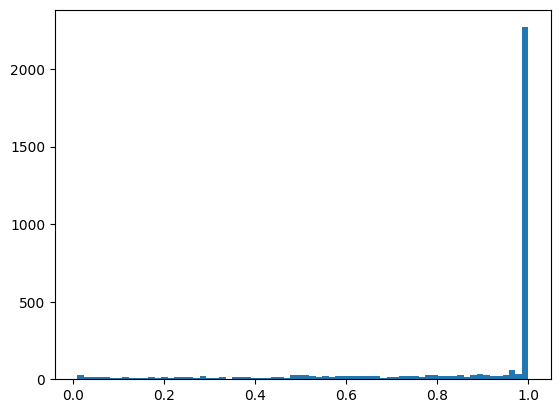

In [ ]:
import matplotlib.pyplot as plt

plt.hist(act_feat[act_feat.target > 0.01].target, bins = 70)

In [ ]:
act_feat.columns

In [ ]:
# Проверка число сезонных признаков
from form_time_features import get_seasonality_features

current_date=pd.to_datetime('2026-04-23')
df_season = get_seasonality_features(current_date)
df_season.head()

In [ ]:
import pandas as pd
import os

# путь к главному файлу
main_file = "data/14 Лимиты мер воздействия ХК.xlsx"

# читаем главный файл
limits_df = pd.read_excel(main_file)

# словарь для результатов
result = {}

for _, row in limits_df.iterrows():
    file_name = row.iloc[0]
    limit = row.iloc[1]

    # пропускаем пустые строки
    if pd.isna(file_name):
        continue

    file_path = os.path.join("data", file_name+".xlsx")

    # читаем файл без заголовков
    df_raw = pd.read_excel(file_path, header=None)

    # 1 строка — название операции
    operation_name = df_raw.iloc[0, 0]

    # 2 строка — заголовки
    df = df_raw.iloc[2:].copy()
    df.columns = df_raw.iloc[1]

    # чистка: убираем #Н/Д
    df = df[df["ЛС"].notna()]

    # сохраняем
    result[operation_name] = {
        "limit": limit,
        "data": df
    }

# теперь result — словарь с данными

In [ ]:
result.keys()

In [ ]:
result["Заявление о выдаче судебного приказа"]

In [ ]:
df2 = pd.read_excel("data/01 Общая информация о ЛС ХК.xlsx", index_col=0)
df2.drop(columns=["Адрес (ГУИД)"], inplace=True)
df2

In [ ]:
from general_information import read_general_information, read_balances, read_actions
from form_time_features import calculate_complex_features
import pandas as pd
# Читаем сальдовую ведомость и удаляем из неё нулевые строки
balances = read_balances()
cols_to_check = balances.columns.drop('ЛС')
balances = balances[(balances[cols_to_check] != 0).any(axis=1)]

# Все другие таблицы должны соответствовать данным id.
ids = balances['ЛС']

# Читаем платёжную таблицу. Удаляем лишние id.
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";", decimal=",")
df_pay = df_pay[df_pay['Номер'].isin(ids)]

# Читаем информацию с булевыми признаками. Удаляем лишние id.
general_df = read_general_information()
general_df = general_df[general_df['ЛС'].isin(ids)]

actions_df = read_actions()

df = calculate_complex_features(df_pay, balances, 3, pd.Timestamp("2025-04-01"))
df

In [ ]:
df.Current_Debt.value_counts()

In [ ]:
from form_train_set import build_master_dataset

df = build_master_dataset(12)

df

In [ ]:
df.info()